In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

train_woe = pd.read_csv("../data/processed/train_woe.csv")
validation_woe = pd.read_csv("../data/processed/validation_woe.csv")
test_woe = pd.read_csv("../data/processed/test_woe.csv")

target = "SeriousDlqin2yrs"

final_variables = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "MonthlyIncome",
    "DebtRatio",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
    "NumberOfTimes90DaysLate"
]

In [2]:
X_train = sm.add_constant(train_woe[final_variables])
y_train = train_woe[target]

model = sm.Logit(y_train, X_train).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.192690
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       SeriousDlqin2yrs   No. Observations:                90000
Model:                          Logit   Df Residuals:                    89991
Method:                           MLE   Df Model:                            8
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                  0.2148
Time:                        18:30:41   Log-Likelihood:                -17342.
converged:                       True   LL-Null:                       -22086.
Covariance Type:            nonrobust   LLR p-value:                     0.000
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -2.6374      0.016   -162.830      0.000      -2.669      -2.606
RevolvingUtilizationOfUnsecuredLines    -0.7385      0.016    -46.800      0.000      -0.769      -0.708
age                                     -0.3993      0.033    -11.951      0.000      -0.465      -0.334
MonthlyIncome                           -0.1889      0.056     -3.376      0.001      -0.299      -0.079
DebtRatio                               -0.8897      0.052    -17.219      0.000      -0.991      -0.788
NumberOfOpenCreditLinesAndLoans          0.2589      0.051      5.031      0.000       0.158       0.360
NumberRealEstateLoansOrLines            -0.6128      0.063     -9.774      0.000      -0.736      -0.490
NumberOfDependents                      -0.3909      0.086     -4.543      0.000      -0.560      -0.222
NumberOfTimes90DaysLate                 -0.7238      0.014    -53.143      0.000      -0.750      -0.697
========================================================================================================
"""

In [3]:
PDO = 20
BASE_SCORE = 600
BASE_ODDS = 20

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

def add_pd_and_score(df, model, variables):
    X = sm.add_constant(df[variables])
    
    df = df.copy()
    df["pd"] = model.predict(X)
    df["logit"] = np.dot(X, model.params)
    df["score"] = offset - factor * df["logit"]
    
    return df

In [4]:
train_scored = add_pd_and_score(train_woe, model, final_variables)
validation_scored = add_pd_and_score(validation_woe, model, final_variables)
test_scored = add_pd_and_score(test_woe, model, final_variables)

In [5]:
score_distribution = pd.DataFrame({
    "dataset": ["Train", "Validation", "Test"],
    "count": [
        len(train_scored),
        len(validation_scored),
        len(test_scored)
    ],
    "mean_score": [
        train_scored["score"].mean(),
        validation_scored["score"].mean(),
        test_scored["score"].mean()
    ],
    "std_score": [
        train_scored["score"].std(),
        validation_scored["score"].std(),
        test_scored["score"].std()
    ],
    "min_score": [
        train_scored["score"].min(),
        validation_scored["score"].min(),
        test_scored["score"].min()
    ],
    "p25_score": [
        train_scored["score"].quantile(0.25),
        validation_scored["score"].quantile(0.25),
        test_scored["score"].quantile(0.25)
    ],
    "median_score": [
        train_scored["score"].median(),
        validation_scored["score"].median(),
        test_scored["score"].median()
    ],
    "p75_score": [
        train_scored["score"].quantile(0.75),
        validation_scored["score"].quantile(0.75),
        test_scored["score"].quantile(0.75)
    ],
    "max_score": [
        train_scored["score"].max(),
        validation_scored["score"].max(),
        test_scored["score"].max()
    ],
    "bad_rate": [
        train_scored[target].mean(),
        validation_scored[target].mean(),
        test_scored[target].mean()
    ]
})

In [6]:
score_distribution

,dataset,count,mean_score,std_score,min_score,p25_score,median_score,p75_score,max_score,bad_rate
0,Train,90000,607.481460,32.685818,479.326210,586.566424,616.891320,632.469521,662.584386,0.066844
1,Validation,30000,607.361236,32.540044,478.657057,586.989024,616.437414,632.313102,658.224366,0.066833
2,Test,30000,607.300926,32.524767,485.008362,586.613608,616.532525,632.210046,661.022306,0.066833


## Decile Analysis за Train / Validation / Test

In [7]:
def decile_analysis(df, dataset_name):
    df = df.copy()
    
    df["score_decile"] = pd.qcut(
        df["score"],
        q=10,
        labels=False,
        duplicates="drop"
    )
    
    result = (
        df
        .groupby("score_decile")
        .agg(
            customers=("score", "count"),
            min_score=("score", "min"),
            max_score=("score", "max"),
            avg_score=("score", "mean"),
            avg_pd=("pd", "mean"),
            bad_rate=(target, "mean")
        )
        .reset_index()
    )
    
    result["dataset"] = dataset_name
    
    return result

In [8]:
train_deciles = decile_analysis(train_scored, "Train")
validation_deciles = decile_analysis(validation_scored, "Validation")
test_deciles = decile_analysis(test_scored, "Test")

all_deciles = pd.concat(
    [train_deciles, validation_deciles, test_deciles],
    ignore_index=True
)

all_deciles

,score_decile,customers,min_score,max_score,avg_score,avg_pd,bad_rate,dataset
0,0,9000,479.326210,565.133618,538.859173,0.316359,0.317000,Train
1,1,9000,565.139354,579.529117,572.236044,0.116538,0.123444,Train
2,2,9000,579.529189,593.974050,586.612449,0.074300,0.079333,Train
3,3,9003,593.976074,606.992800,600.824873,0.046686,0.045763,Train
4,4,8998,606.994642,616.891320,612.204875,0.031862,0.031896,Train
5,5,8999,616.891524,623.732772,620.401773,0.024112,0.024781,Train
6,6,9000,623.734790,629.642140,626.795675,0.019403,0.015111,Train
7,7,9000,629.645983,635.432076,632.494305,0.015981,0.015222,Train
8,8,9007,635.432273,641.302410,638.317912,0.013098,0.009548,Train
9,9,8993,641.302834,662.584386,646.078266,0.010097,0.006338,Train


In [9]:
validation_deciles

,score_decile,customers,min_score,max_score,avg_score,avg_pd,bad_rate,dataset
0,0,3000,478.657057,565.183230,539.082721,0.314455,0.310000,Validation
1,1,3000,565.206082,579.644614,572.243328,0.116487,0.127333,Validation
2,2,3000,579.644915,593.974747,586.899021,0.073601,0.081667,Validation
3,3,3000,593.975064,606.677789,600.630415,0.046974,0.047000,Validation
4,4,3000,606.678638,616.432627,611.664863,0.032438,0.032333,Validation
5,5,3000,616.442200,623.354161,620.003201,0.024441,0.027333,Validation
6,6,3000,623.355627,629.444952,626.481047,0.019614,0.014000,Validation
7,7,3000,629.445493,635.274825,632.354410,0.016058,0.011000,Validation
8,8,3002,635.277501,641.274806,638.196015,0.013154,0.009993,Validation
9,9,2998,641.283244,658.224366,646.062586,0.010102,0.007672,Validation


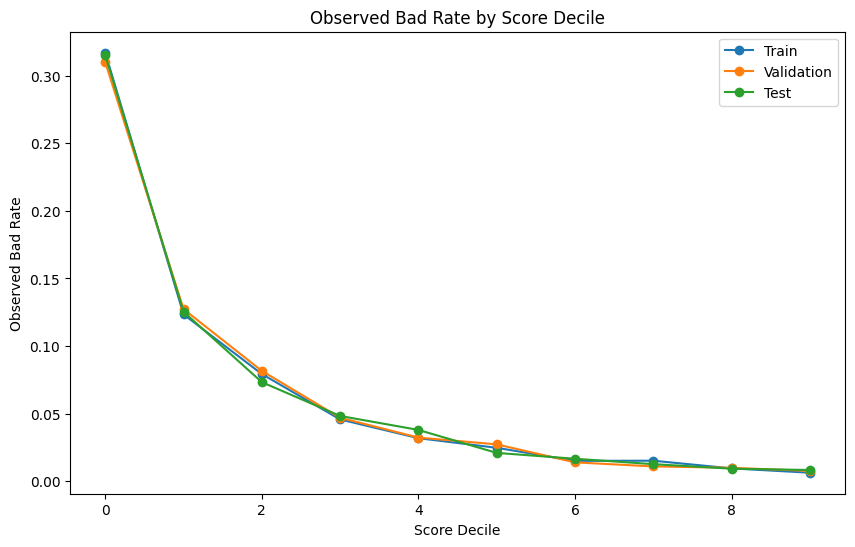

In [10]:
plt.figure(figsize=(10, 6))

for dataset_name, decile_df in [
    ("Train", train_deciles),
    ("Validation", validation_deciles),
    ("Test", test_deciles)
]:
    plt.plot(
        decile_df["score_decile"],
        decile_df["bad_rate"],
        marker="o",
        label=dataset_name
    )

plt.xlabel("Score Decile")
plt.ylabel("Observed Bad Rate")
plt.title("Observed Bad Rate by Score Decile")
plt.legend()
plt.show()

## Cut-off fit

In [11]:
def cutoff_summary(df, cutoff_score, dataset_name):
    approved = df[df["score"] >= cutoff_score]
    rejected = df[df["score"] < cutoff_score]
    
    return {
        "dataset": dataset_name,
        "cutoff_score": cutoff_score,
        "approval_rate": len(approved) / len(df),
        "rejection_rate": len(rejected) / len(df),
        "approved_bad_rate": approved[target].mean(),
        "rejected_bad_rate": rejected[target].mean(),
        "bad_capture_rate": rejected[target].sum() / df[target].sum()
    }

In [12]:
cutoff_score = 600

cutoff_fit = pd.DataFrame([
    cutoff_summary(train_scored, cutoff_score, "Train"),
    cutoff_summary(validation_scored, cutoff_score, "Validation"),
    cutoff_summary(test_scored, cutoff_score, "Test")
])

cutoff_fit

,dataset,cutoff_score,approval_rate,rejection_rate,approved_bad_rate,rejected_bad_rate,bad_capture_rate
0,Train,600,0.657689,0.342311,0.019124,0.158530,0.811835
1,Validation,600,0.655900,0.344100,0.019261,0.157512,0.810973
2,Test,600,0.655333,0.344667,0.019786,0.156286,0.805985


In [13]:
train_scored.to_csv("../data/processed/train_scored.csv", index=False)
validation_scored.to_csv("../data/processed/validation_scored.csv", index=False)
test_scored.to_csv("../data/processed/test_scored.csv", index=False)

score_distribution.to_csv("../data/outputs/score_distribution.csv", index=False)
all_deciles.to_csv("../data/outputs/score_decile_analysis.csv", index=False)
cutoff_fit.to_csv("../data/outputs/cutoff_fit_summary.csv", index=False)

## Score Run & Fit Summary

The final scorecard was applied to the train, validation and test samples.

Score distributions are highly stable across all datasets. Mean score values are almost identical across train, validation and test, indicating no material sample shift.

The decile analysis confirms strong rank ordering. The lowest score decile shows an observed bad rate of approximately 31%, while the highest score decile shows an observed bad rate below 1%.

At the proposed cut-off score of 600, the scorecard produces stable credit policy outcomes across all samples:

- Approval Rate: approximately 65.5%
- Approved Portfolio Bad Rate: approximately 1.9% - 2.0%
- Bad Capture Rate: approximately 81%

The results indicate that the selected cut-off is stable and that the scorecard generalizes well across unseen samples.